In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [13]:
!pip install scikit-fuzzy

In [14]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.cluster import KMeans
import skfuzzy as fuzz

from sklearn.metrics import jaccard_score
from sklearn.metrics import f1_score

In [15]:
BASE_PATH = "/kaggle/input/bccd-dataset-with-mask/BCCD Dataset with mask"

TRAIN_IMG = os.path.join(BASE_PATH, "train/original")
TRAIN_MASK = os.path.join(BASE_PATH, "train/mask")

TEST_IMG = os.path.join(BASE_PATH, "test/original")
TEST_MASK = os.path.join(BASE_PATH, "test/mask")

In [16]:
def load_image_mask_pairs(img_dir, mask_dir):
    images = []
    masks = []
    
    img_files = sorted(os.listdir(img_dir))
    
    for file in tqdm(img_files):
        img_path = os.path.join(img_dir, file)
        mask_path = os.path.join(mask_dir, file.replace('.jpg', '.png'))
        
        if not os.path.exists(mask_path):
            continue
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        mask = cv2.imread(mask_path, 0)
        
        images.append(img)
        masks.append(mask)
        
    return images, masks

In [17]:
test_images, test_masks = load_image_mask_pairs(TEST_IMG, TEST_MASK)

print("Loaded:", len(test_images))

100%|██████████| 159/159 [00:12<00:00, 12.70it/s]

Loaded: 159


In [27]:
def preprocess(img):
    img = cv2.resize(img, (128,128))
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    return lab[:,:,0]   # L channel only

In [28]:
def segment_kmeans(img, n_clusters=3):
    L = preprocess(img)
    pixels = L.reshape((-1,1)).astype(np.float32)
    
    kmeans = KMeans(n_clusters=n_clusters, n_init=5, random_state=42)
    labels = kmeans.fit_predict(pixels)
    
    return labels.reshape(L.shape)

In [29]:
def segment_fcm(img, n_clusters=3):
    L = preprocess(img)
    pixels = L.reshape((1,-1)).astype(np.float64)
    
    cntr, u, _, _, _, _, _ = cmeans(
        pixels,
        n_clusters,
        2,
        error=0.01,
        maxiter=100
    )
    
    labels = np.argmax(u, axis=0)
    return labels.reshape(L.shape)

In [21]:
def extract_boundary(segmentation):
    kernel = np.ones((3, 3), np.uint8)
    boundary = cv2.morphologyEx(segmentation.astype(np.uint8), cv2.MORPH_GRADIENT, kernel)
    return (boundary > 0).astype(np.uint8)

In [30]:
def cluster_to_binary(segmented, img):
    img_resized = cv2.resize(img, (128,128))
    gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    
    clusters = np.unique(segmented)
    means = [np.mean(gray[segmented==c]) for c in clusters]
    
    nucleus_cluster = clusters[np.argmin(means)]
    
    return (segmented == nucleus_cluster).astype(np.uint8)

In [31]:
from skfuzzy.cluster import cmeans

In [32]:
def extract_boundary(mask):
    kernel = np.ones((3,3), np.uint8)
    boundary = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_GRADIENT, kernel)
    return (boundary > 0).astype(np.uint8)

In [33]:
def calculate_boundary_metrics(gt, pred):

    TP = np.logical_and(gt==1, pred==1).sum()
    TN = np.logical_and(gt==0, pred==0).sum()
    FP = np.logical_and(gt==0, pred==1).sum()
    FN = np.logical_and(gt==1, pred==0).sum()

    accuracy = (TP+TN)/(TP+TN+FP+FN)
    precision = TP/(TP+FP) if TP+FP>0 else 0
    recall = TP/(TP+FN) if TP+FN>0 else 0
    f1 = 2*(precision*recall)/(precision+recall) if precision+recall>0 else 0

    return accuracy, precision, recall, f1

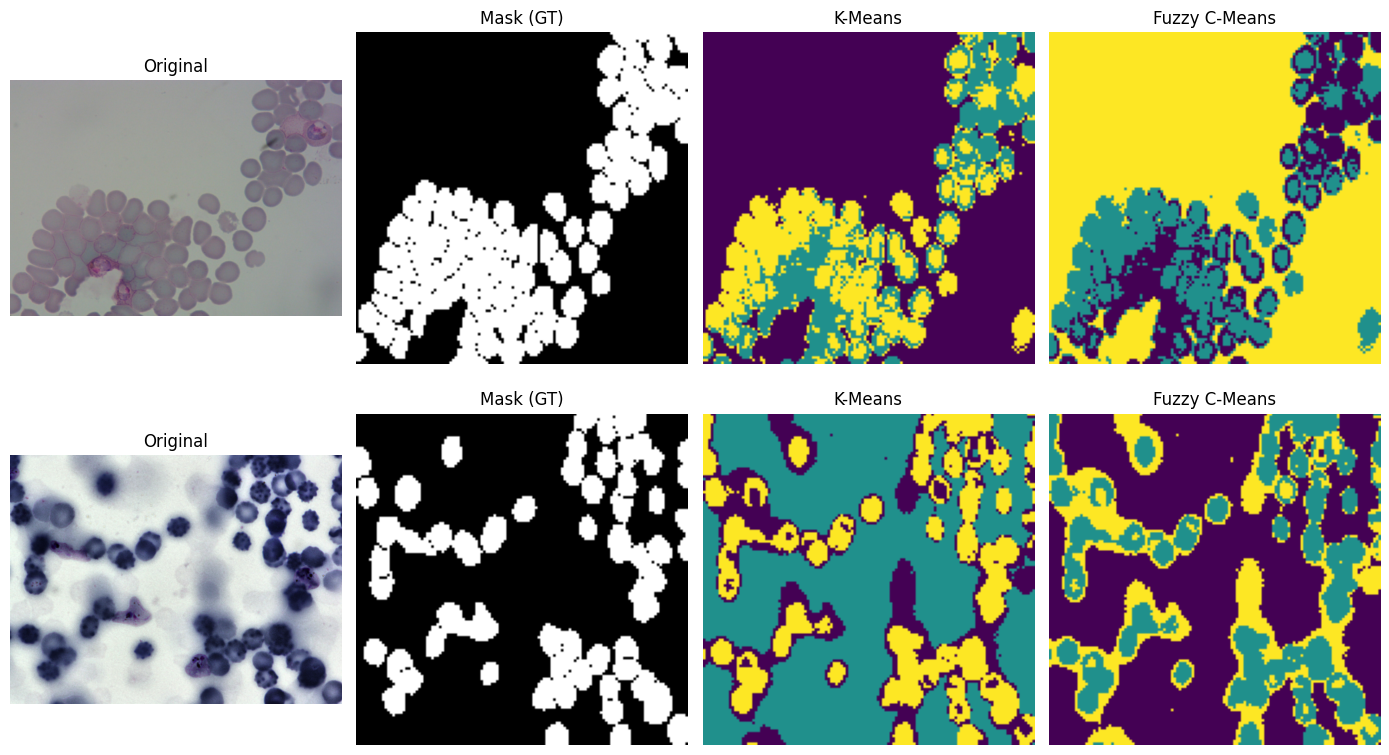

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(14,8))

for i in range(2):
    img = test_images[i]
    mask = test_masks[i]
    
    mask_resized = cv2.resize(mask, (128,128))
    mask_bin = (mask_resized>0).astype(np.uint8)

    kmeans_seg = segment_kmeans(img)
    fcm_seg = segment_fcm(img)

    axes[i,0].imshow(img)
    axes[i,0].set_title("Original")
    axes[i,0].axis("off")

    axes[i,1].imshow(mask_bin, cmap='gray')
    axes[i,1].set_title("Mask (GT)")
    axes[i,1].axis("off")

    axes[i,2].imshow(kmeans_seg, cmap='viridis')
    axes[i,2].set_title("K-Means")
    axes[i,2].axis("off")

    axes[i,3].imshow(fcm_seg, cmap='viridis')
    axes[i,3].set_title("Fuzzy C-Means")
    axes[i,3].axis("off")

plt.tight_layout()
plt.show()

In [35]:
kmeans_scores = {'accuracy': [], 'precision': [], 'recall': [], 'f1_score': []}
fcm_scores = {'accuracy': [], 'precision': [], 'recall': [], 'f1_score': []}

for img, mask in tqdm(zip(test_images, test_masks), total=len(test_images)):
    
    mask = cv2.resize(mask, (128,128))
    mask = (mask>0).astype(np.uint8)
    
    # KMeans
    km_seg = segment_kmeans(img)
    km_bin = cluster_to_binary(km_seg, img)
    
    # FCM
    fm_seg = segment_fcm(img)
    fm_bin = cluster_to_binary(fm_seg, img)
    
    gt_boundary = extract_boundary(mask)
    km_boundary = extract_boundary(km_bin)
    fm_boundary = extract_boundary(fm_bin)
    
    km_acc, km_prec, km_rec, km_f1 = calculate_boundary_metrics(gt_boundary, km_boundary)
    fm_acc, fm_prec, fm_rec, fm_f1 = calculate_boundary_metrics(gt_boundary, fm_boundary)
    
    kmeans_scores['accuracy'].append(km_acc)
    kmeans_scores['precision'].append(km_prec)
    kmeans_scores['recall'].append(km_rec)
    kmeans_scores['f1_score'].append(km_f1)
    
    fcm_scores['accuracy'].append(fm_acc)
    fcm_scores['precision'].append(fm_prec)
    fcm_scores['recall'].append(fm_rec)
    fcm_scores['f1_score'].append(fm_f1)

100%|██████████| 159/159 [00:43<00:00,  3.63it/s]


In [36]:
print("K-Means Boundary Metrics (dataset average)")
for key in kmeans_scores:
    print(f"  {key}: {np.mean(kmeans_scores[key]):.4f}")

print("\nFuzzy C-Means Boundary Metrics (dataset average)")
for key in fcm_scores:
    print(f"  {key}: {np.mean(fcm_scores[key]):.4f}")

K-Means Boundary Metrics (dataset average)
  accuracy: 0.8036
  precision: 0.6453
  recall: 0.6904
  f1_score: 0.6619

Fuzzy C-Means Boundary Metrics (dataset average)
  accuracy: 0.7970
  precision: 0.6349
  recall: 0.6736
  f1_score: 0.6488
